# Analyse 2: Zeitliche Muster bei Parking Violations FY2023–FY2025

Gibt es zeitliche Muster bei Parking Violations nach Monat, Wochentag und Tageszeit?

In [66]:
import pyspark.sql.functions as f
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pyspark.sql import SparkSession

# Alte (evtl. tote) Session sauber wegräumen
try:
    SparkSession.builder.getOrCreate().stop()
except Exception:
    pass

# Auch den globalen aktiven Context auf None setzen, damit getOrCreate() wirklich neu baut
from pyspark import SparkContext
SparkContext._active_spark_context = None

# Jetzt frisch aufbauen

# Auch den globalen aktiven Context auf None setzen, damit getOrCreate() wirklich neu baut
from pyspark import SparkContext
SparkContext._active_spark_context = None

# Jetzt frisch aufbauen
spark = SparkSession.builder \
    .appName("BDLC_Parking_Violations_ViolationCode") \
    .master("spark://bdlc-012.bdlc.ls.eee.intern:7077") \
    .config("spark.cores.max", "12") \
    .getOrCreate()


spark.sparkContext.setLogLevel("WARN")

# Kontrolle: was hat diese Session tatsächlich bekommen?
cconf = spark.sparkContext.getConf()
print("cores.max     :", cconf.get("spark.cores.max"))
print("executor.cores:", cconf.get("spark.executor.cores", "(Default)"))
print("executor.mem  :", cconf.get("spark.executor.memory", "(Default)"))

# Verifizieren, dass der Context wirklich lebt
print("SparkContext active:", not spark.sparkContext._jsc.sc().isStopped())
spark

cores.max     : 12
executor.cores: 4
executor.mem  : 15g
SparkContext active: True


In [67]:
# Daten laden
processed_path = "hdfs:///parking_violations/processed/parking_violations_cleaned_v5"
df = spark.read.parquet(processed_path)
df.count()

49660402

## Analyse A — Monatliche Verteilung

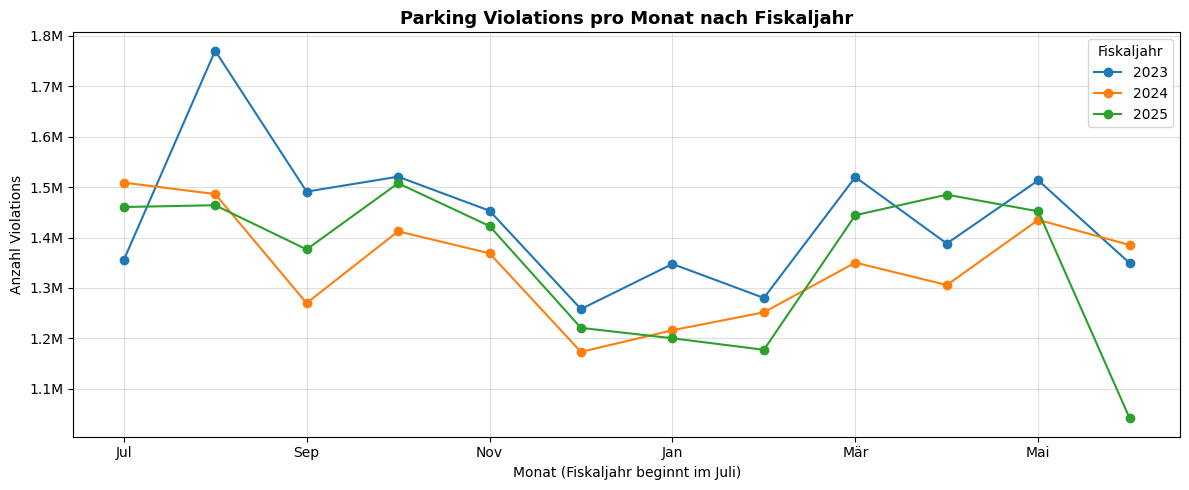

In [56]:
# Aggregation: Anzahl Violations pro Fiskaljahr und Fiscal Month
monthly = df.filter("is_complete_fy") \
    .groupBy("fy", "fm") \
    .count() \
    .orderBy("fy", "fm") \
    .toPandas()

# Fiscal-Month-Labels: 1=Jul, ..., 6=Dez, 7=Jan, ..., 12=Jun
fm_labels = {1:"Jul", 2:"Aug", 3:"Sep", 4:"Okt", 5:"Nov", 6:"Dez",
             7:"Jan", 8:"Feb", 9:"Mär", 10:"Apr", 11:"Mai", 12:"Jun"}

# Pivot: Fiscal Months als Zeilen, Fiskaljahre als Spalten
pivot_m = monthly.pivot(index="fm", columns="fy", values="count")
pivot_m.index = pivot_m.index.map(fm_labels)

# Plot: Line-Chart, eine Linie pro Fiskaljahr
fig, ax = plt.subplots(figsize=(12, 5))
pivot_m.plot(marker="o", ax=ax)
ax.set_title("Parking Violations pro Monat nach Fiskaljahr", fontsize=13, fontweight="bold")
ax.set_xlabel("Monat (Fiskaljahr beginnt im Juli)")
ax.set_ylabel("Anzahl Violations")
# Y-Achse in Millionen formatieren (z.B. 1.2M statt 1200000)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.grid(True, alpha=0.4)
ax.legend(title="Fiskaljahr")
plt.tight_layout()
plt.show()

### Resultate — Monatliche Verteilung nach Fiskaljahr

Alle drei Fiskaljahre zeigen dasselbe saisonale Muster: Die Violations-Zahlen 
sind im Sommer (Jul–Sep) am höchsten und sinken im Winter (Nov–Feb) auf den 
Jahrestiefstwert. Auffällig ist der markante Peak im August 2022 (FY2023, 
blau), dieser entspricht dem in Analyse 1 dokumentierten Anstieg bei Code 36 
(Schulzone Tempolimit), der auf die Aktivierung der 24/7-Kameraüberwachung in 
750 Schulzonen ab dem 1. August 2022 zurückzuführen ist.

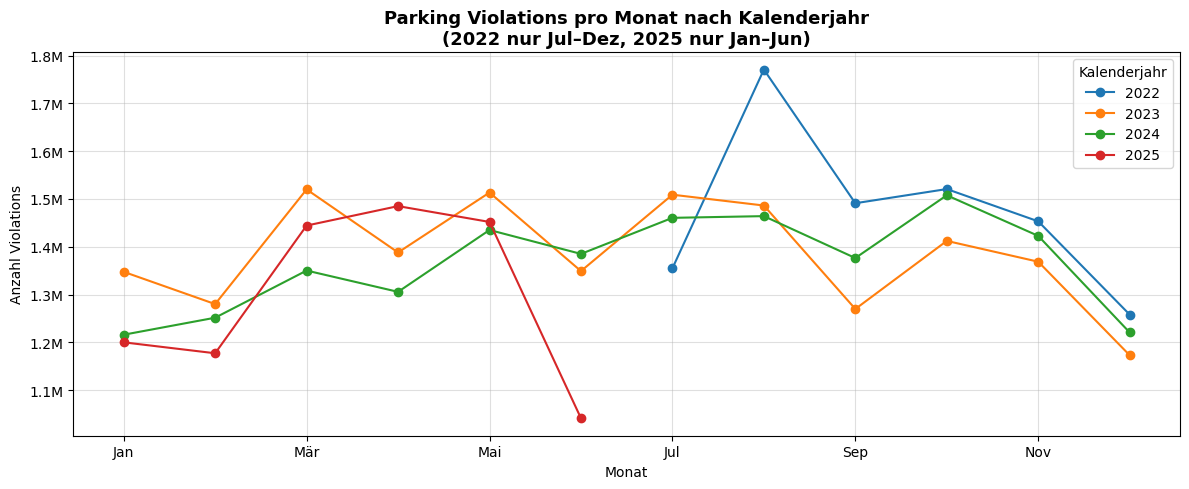

In [57]:
# Aggregation nach Kalenderjahr und Monat
monthly = df.groupBy("issue_year", "issue_month") \
    .count() \
    .orderBy("issue_year", "issue_month") \
    .toPandas()

month_labels = {1:"Jan", 2:"Feb", 3:"Mär", 4:"Apr", 5:"Mai", 6:"Jun",
                7:"Jul", 8:"Aug", 9:"Sep", 10:"Okt", 11:"Nov", 12:"Dez"}

pivot_m = monthly.pivot(index="issue_month", columns="issue_year", values="count")
pivot_m.index = pivot_m.index.map(month_labels)

fig, ax = plt.subplots(figsize=(12, 5))
pivot_m.plot(marker="o", ax=ax)
ax.set_title("Parking Violations pro Monat nach Kalenderjahr\n(2022 nur Jul–Dez, 2025 nur Jan–Jun)", 
             fontsize=13, fontweight="bold")
ax.set_xlabel("Monat")
ax.set_ylabel("Anzahl Violations")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.grid(True, alpha=0.4)
ax.legend(title="Kalenderjahr")
plt.tight_layout()
plt.show()

### Resultate — Monatliche Verteilung nach Kalenderjahr

Der Kalender-Chart macht den Unterschied zur Fiskaljahrlogik sichtbar: 2022 
erscheint nur mit Jul–Dez, 2025 nur mit Jan–Jun. Der starke Einbruch im 
Jun 2025 ist vermutlich darauf zurückzuführen, dass die Daten für diesen 
Monat zum Zeitpunkt des Datenexports noch nicht vollständig erfasst waren. 

## Analyse B — Wochentag (normalisiert)

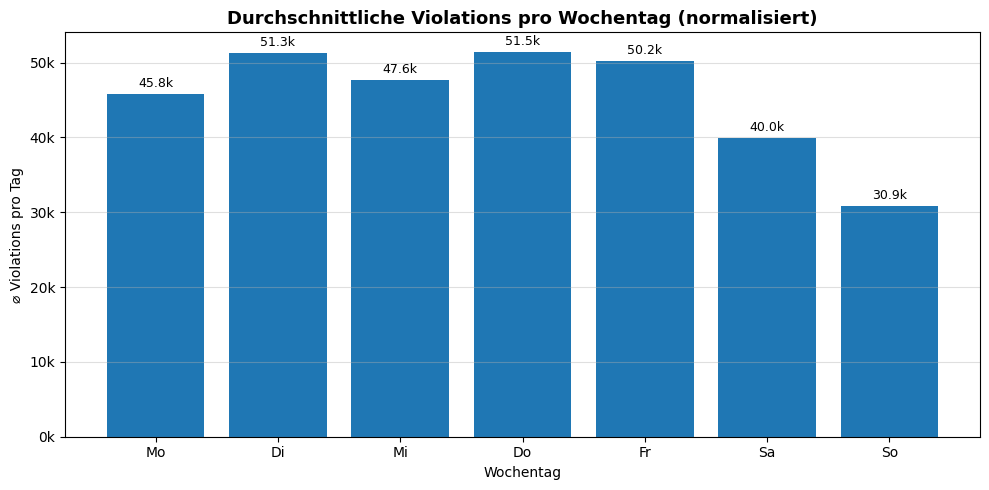

In [59]:
weekday_labels = {1:"So", 2:"Mo", 3:"Di", 4:"Mi", 5:"Do", 6:"Fr", 7:"Sa"}

# Nur vollständige Fiskaljahre (vermeidet Verzerrung durch Halbjahre 2022/2025)
df_wd = df.filter("is_complete_fy")

# Rohzählung pro Wochentag
weekday = df_wd.groupBy("issue_weekday").count() \
    .orderBy("issue_weekday").toPandas()

# Anzahl einzigartiger Tage pro Wochentag (für Normalisierung)
days_per_weekday = df_wd.select("issue_date_parsed", "issue_weekday") \
    .distinct() \
    .groupBy("issue_weekday").count() \
    .withColumnRenamed("count", "num_days") \
    .toPandas()

# Durchschnitt berechnen: Violations / Anzahl Tage dieses Wochentags
weekday = weekday.merge(days_per_weekday, on="issue_weekday")
weekday["avg_per_day"] = weekday["count"] / weekday["num_days"]
weekday["label"] = weekday["issue_weekday"].map(weekday_labels)

# Wochentagsreihenfolge: Mo, Di, Mi, Do, Fr, Sa, So (intuitiver als So-Sa)
weekday_order = [2, 3, 4, 5, 6, 7, 1]
weekday["sort_order"] = weekday["issue_weekday"].map({v: i for i, v in enumerate(weekday_order)})
weekday = weekday.sort_values("sort_order")

# Plot: Balkendiagramm normalisiert
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(weekday["label"], weekday["avg_per_day"], color="#1f77b4")
ax.set_title("Durchschnittliche Violations pro Wochentag (normalisiert)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Wochentag")
ax.set_ylabel("⌀ Violations pro Tag")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
ax.grid(True, axis="y", alpha=0.4)

# Werte auf Balken anzeigen — Offset proportional zum Max statt fix
y_max = weekday["avg_per_day"].max()
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + y_max * 0.01, f"{h/1e3:.1f}k",
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

### Resultate — Wochentag (normalisiert)

Donnerstag (51.5k) und Dienstag (51.3k) weisen die höchsten Violations pro Tag 
auf, Sonntag (30.9k) und Samstag (40.0k) die niedrigsten.

## Analyse C — Tageszeit

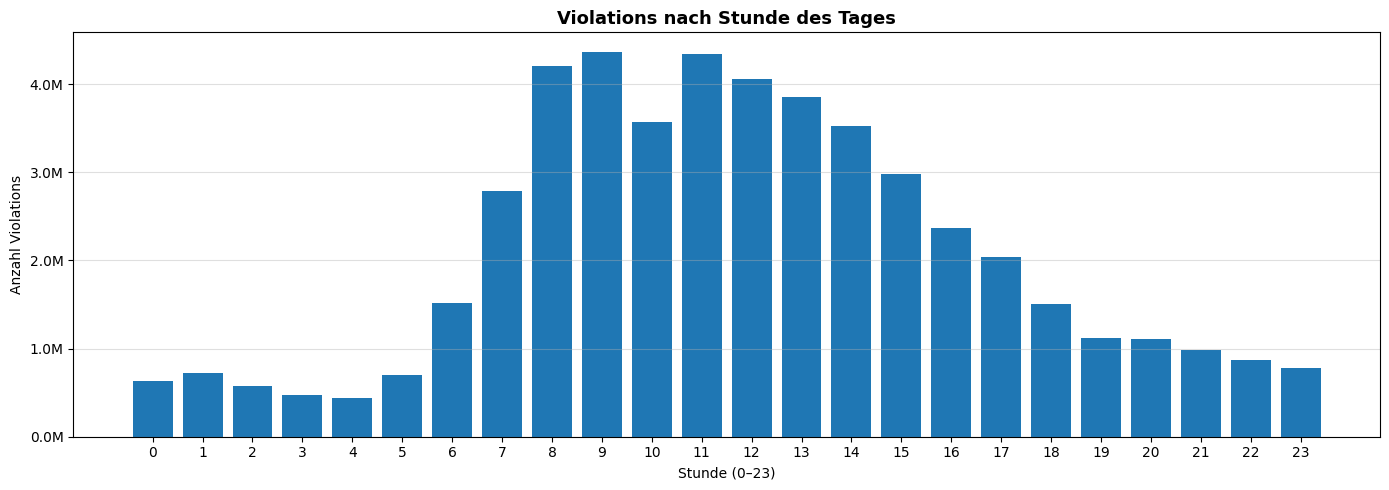

In [60]:
hourly = df.filter("is_complete_fy") \
    .filter(f.col("violation_hour").isNotNull()) \
    .groupBy("violation_hour").count() \
    .orderBy("violation_hour").toPandas()

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(hourly["violation_hour"], hourly["count"], color="#1f77b4")

ax.set_title("Violations nach Stunde des Tages", fontsize=13, fontweight="bold")
ax.set_xlabel("Stunde (0–23)")
ax.set_ylabel("Anzahl Violations")
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.grid(True, axis="y", alpha=0.4)

plt.tight_layout()
plt.show()

### Resultate — Tageszeit

Der Peak liegt zwischen 8 und 14 Uhr. Nachts (0–5 Uhr) werden kaum 
Violations ausgestellt.

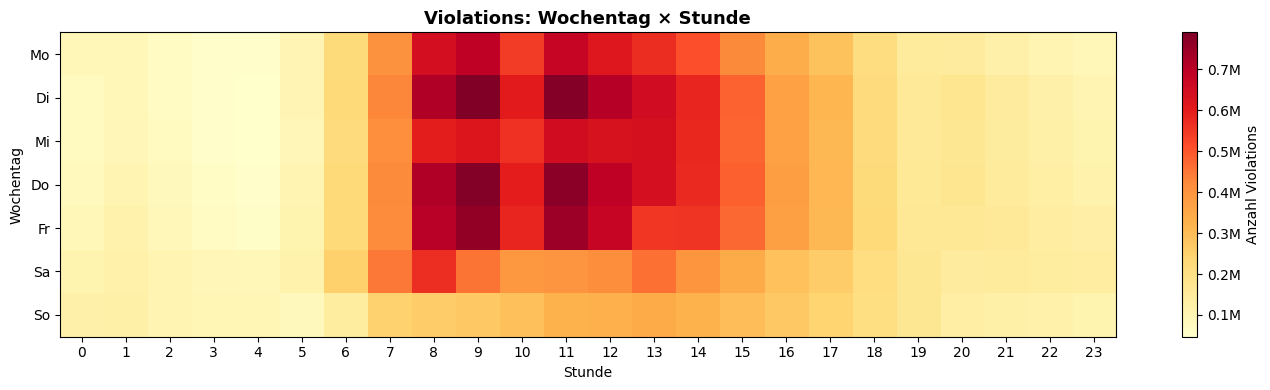

In [61]:
import numpy as np

# Aggregation: Wochentag × Stunde (nur volle FYs, nur Records mit gültiger Stunde)
heat = df.filter("is_complete_fy") \
    .filter(f.col("violation_hour").isNotNull()) \
    .groupBy("issue_weekday", "violation_hour") \
    .count() \
    .toPandas()

# Pivot: Wochentage als Zeilen, Stunden als Spalten
pivot_h = heat.pivot(index="issue_weekday", columns="violation_hour", values="count")

# Wochentagsreihenfolge Mo-So (intuitiver als So-Sa, das Spark per Default liefert)
weekday_order = [2, 3, 4, 5, 6, 7, 1]
pivot_h = pivot_h.reindex(weekday_order)
pivot_h.index = pivot_h.index.map(weekday_labels)

# Stunden 0..23 in Reihenfolge
pivot_h = pivot_h.sort_index(axis=1)

# Plot
fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(pivot_h.values, cmap="YlOrRd", aspect="auto")

# Achsenbeschriftung
ax.set_xticks(np.arange(len(pivot_h.columns)))
ax.set_xticklabels(pivot_h.columns)
ax.set_yticks(np.arange(len(pivot_h.index)))
ax.set_yticklabels(pivot_h.index)
ax.set_xlabel("Stunde")
ax.set_ylabel("Wochentag")
ax.set_title("Violations: Wochentag × Stunde", fontsize=13, fontweight="bold")

# Colorbar: in Millionen formatieren
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Anzahl Violations")
cbar.formatter = mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M")
cbar.update_ticks()

plt.tight_layout()
plt.show()

### Resultate — Wochentag × Stunde

Die Heatmap bestätigt: Dienstag und Donnerstag zwischen 9 und 12 Uhr sind 
die absoluten Hotspots. An Wochenenden bleibt die Intensität über alle 
Tageszeiten deutlich tiefer.

## Plausibilitätskontrolle

Um zu verstehen, warum der Gesamtpeak zwischen 8 und 14 Uhr entsteht, 
analysieren wir die vier häufigsten Violation-Codes einzeln nach Stunde. 
Ziel ist es, aus unseren eigenen Daten heraus zu erklären, ob und wie 
verschiedene Enforcement-Typen zum beobachteten Muster beitragen.

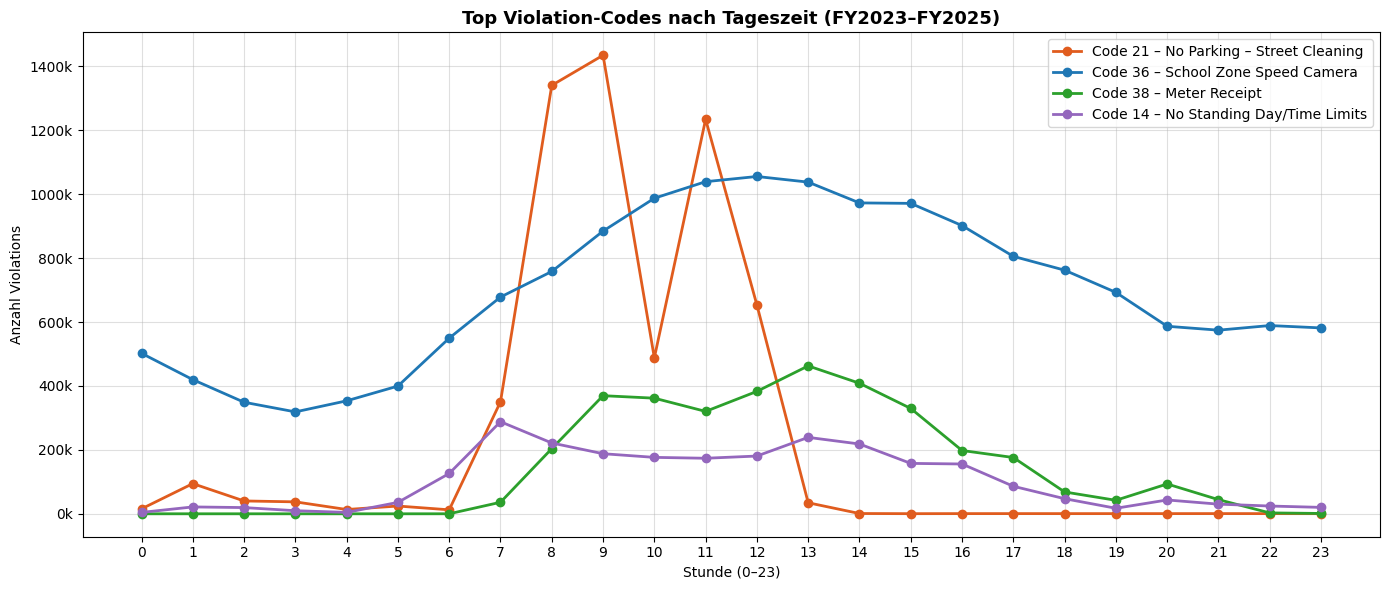

In [81]:
# Plausibilitätskontrolle: Top Violation-Codes nach Stunde
codes = [
    ("21", "No Parking – Street Cleaning", "#e05c1e"),
    ("36", "School Zone Speed Camera",     "#1f77b4"),
    ("38", "Meter Receipt",                "#2ca02c"),
    ("14", "No Standing Day/Time Limits",  "#9467bd"),
]

fig, ax = plt.subplots(figsize=(14, 6))

for code, label, color in codes:
    temp = df.filter("is_complete_fy") \
        .filter(f.col("violation_code") == code) \
        .filter(f.col("violation_hour").isNotNull()) \
        .groupBy("violation_hour").count() \
        .orderBy("violation_hour").toPandas()

    ax.plot(temp["violation_hour"], temp["count"],
            marker="o", color=color, label=f"Code {code} – {label}", linewidth=2)

ax.set_title("Top Violation-Codes nach Tageszeit (FY2023–FY2025)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Stunde (0–23)")
ax.set_ylabel("Anzahl Violations")
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
ax.grid(True, alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

### Befunde pro Violation-Code

**Code 21 — No Parking Street Cleaning**
Code 21 zeigt den klarsten zeitlichen Bezug aller vier Codes: Fast 
ausschliesslich zwischen 8 und 13 Uhr aktiv, danach nahezu null 
Violations. Die Alternate Side Parking Regelung (ASP) verpflichtet 
Fahrzeughalter in NYC, ihr Auto an bestimmten Tagen und Stunden 
wegzufahren, damit Strassenreinigungsfahrzeuge den Randstein säubern 
können.
Wer sein Fahrzeug stehen lässt, erhält einen Strafzettel. Der enge 
Morgenpeak von Code 21 entspricht diesen Zeitfenstern direkt und 
erklärt einen wesentlichen Teil des Morgenpeaks im Gesamtchart.


**Code 36 — School Zone Speed Camera**
Als einziger Code bleibt Code 36 auch nachts aktiv (300–500k Violations
zwischen 0 und 5 Uhr), da die Kameras seit August 2022 rund um die Uhr
laufen (vgl. Analyse 1). Der Peak liegt bei 10–14 Uhr und fällt mit
erhöhtem Schulverkehr und allgemeiner Tagesaktivität zusammen. Aufgrund
seines grossen Volumens (16.77M Violations) ist Code 36 der stärkste
Einzeltreiber des Gesamtpeaks im Mittag.

**Code 38 — Fail to Display Meter Receipt**
Nahezu null vor 7 Uhr, klarer Peak bei 13–14 Uhr, Abfall nach 17 Uhr.
Parkuhren sind in NYC typischerweise während der Geschäftszeiten aktiv —
diese Verteilung spiegelt das direkt wider. Violations entstehen wenn
Fahrer den Beleg nicht sichtbar auslegen oder vergessen nachzuzahlen,
naturgemäss während der Arbeits- und Einkaufszeiten.

**Code 14 — No Standing Day/Time Limits**
Auffälliges Doppelpeak-Muster: ein erster Peak bei 7 Uhr (Morgenrush)
und ein zweiter bei 13–14 Uhr. No-Standing Regeln gelten in NYC
typischerweise während spezifischer Tagesstunden — dieses Muster
spiegelt die klassischen Rush-Hour-Zeiten wider.

### Gesamtbefund Tageszeit

Die vier Codes zeigen unterschiedliche Stundenmuster, überlagern sich
aber alle im Fenster 7–15 Uhr. Der in Analyse C beobachtete Gesamtpeak
ist damit nicht auf eine einzige Ursache zurückzuführen, sondern das
Ergebnis verschiedener Enforcement-Typen mit je eigener zeitlicher Logik:

| Code | Typ | Peak |
|------|-----|------|
| 21 | Street Cleaning (ASP) | 8–13h |
| 36 | Schulzone Kamera | 10–14h (ganztags aktiv) |
| 38 | Parkuhr | 8–17h, Schwerpunkt 13–14h |
| 14 | No Standing | 7h + 13–14h (Rush Hour) |

Eine vollständige Zerlegung aller Violation-Typen würde den Rahmen
dieser Analyse sprengen.

### Befund Wochentag

Sonntags sind ASP und Parkuhren in NYC generell ausgesetzt, was den
tiefsten Wert am Sonntag (30.9k) direkt erklärt. Samstags gilt ASP nur
auf einem Teil der Strassen, woraus der ebenfalls tiefere Wert (40.0k)
resultiert. Hinzu kommt, dass an Wochenenden generell weniger
Fahrverkehr herrscht und damit weniger Fahrzeuge auf der Strasse
parkiert sind, was die tieferen Violations-Zahlen zusätzlich begünstigt.

### Befund Saisonalität

Das saisonale Muster — höhere Violations im Sommer, tiefere im Winter —
entspricht dem in Analyse 1 dokumentierten allgemeinen Verkehrsaufkommen
in NYC. Weniger Fahrverkehr im Winter bedeutet weniger parkierte Fahrzeuge
und damit weniger Violations (vgl. Analyse 1, Quelle [1]).


[1] Gardner, D. R. (n.d.). Seasonal trends in NYC traffic: STL part I.
    gardner.fyi. http://www.gardner.fyi/blog/STL-Part-I/

## Interpretation

- **Monatlich:** Alle drei Fiskaljahre zeigen dasselbe saisonale Muster.
  Sommer höher, Winter tiefer. Der markante Peak im August 2022 (FY2023)
  ist auf die Aktivierung der 24/7-Schulzonenüberwachung zurückzuführen
  (vgl. Analyse 1, Code 36).

- **Wochentag:** Das Werktag-Wochenende-Gefälle ist klar: An Sonntagen
  sind ASP und Parkuhren ausgesetzt, was den tiefsten Wert (30.9k) direkt
  erklärt.

- **Tageszeit:** Der Peak zwischen 8 und 14 Uhr entsteht durch die Überlagerung mehrerer Violation-Typen: Street Cleaning (8–13h), Schulzonenkameras (ganztags), Parkuhren (8–17h) und No-Standing-Regeln (Rush-Hour). Die Heatmap bestätigt: Di/Do zwischen 9 und 12 Uhr sind die absoluten Hotspots.

## Fazit Analyse 2

Die Frage, ob es zeitliche Muster bei Parking Violations gibt, lässt sich klar mit Ja beantworten, auf allen drei untersuchten Dimensionen zeigen sich konsistente Strukturen.
Monatlich folgen die Violations dem saisonalen Verkehrsaufkommen der Stadt. Auf Wochentagesebene dominieren die Werktage deutlich, wobei Sonntag als regelungsfreier Tag klar heraussticht. Auf Tagesebene konzentrieren sich die Violations zwischen 8 und 14 Uhr, nicht wegen einer einzigen Ursache, sondern weil verschiedene Violation-Typen mit je eigener zeitlicher Logik in diesem Fenster zusammenfallen.
Die Analyse zeigt damit, dass Parking Violations in NYC einem klar strukturierten zeitlichen Rhythmus folgen, der eng mit dem städtischen Alltag, Arbeitszeiten, Schulbetrieb und Reinigungszyklen, verknüpft ist.

In [82]:
spark.stop()